<small><font color=gray>Notebook author: <a href="https://www.linkedin.com/in/olegmelnikov/" target="_blank">Oleg Melnikov</a> ©2021 onwards</font></small><hr style="margin:0;background-color:silver">

**<font size=6>🧬Genomics</font>**. [**Instructions**](https://colab.research.google.com/drive/1riOGrE_Fv-yfIbM5V4pgJx4DWcd92cZr#scrollTo=ITaPDPIQEgXV) for running Colabs.

<details>
  <summary><small>Sharing consent: <mark>[ X ]</mark></summary>
  <div>
We consent to sharing our Colab (after the assignment ends) with other students/instructors for educational purposes. We understand that sharing is <b>optional</b> and this decision will not affect our grade in any way. <font color=gray><i>
Instructions: If ok with sharing your Colab for educational purposes, leave "X" in the check box.</i></font></small></div>

<strong><font color=red size=5>IF POSSIBLE, PLEASE CONNECT TO T4 HIGH RAM RUNTIME BEFORE RUNNING THIS NOTEBOOK. WE GAVE UP ON THE RUNTIME REQUIREMENT AND JUST FOCUSED ON GETTING THE BEST SCORE POSSIBLE, SORRY IN ADVANCE.

In [ ]:
from google.colab import drive; drive.mount('/content/drive')   # OK to enable, if your kaggle.json is stored in Google Drive

Mounted at /content/drive


In [ ]:
!mkdir -p ~/.kaggle                               # .kaggle folder must contain kaggle.json for kaggle executable to properly authenticate you to Kaggle.com
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json >>log  # First, download kaggle.json from kaggle.com (in Account page) and place it in the root of mounted Google Drive
!cp kaggle.json ~/.kaggle/kaggle.json >> log       # Alternative location of kaggle.json (without a connection to Google Drive)
!chmod 600 ~/.kaggle/kaggle.json                  # give only the owner full read/write access to kaggle.json
!kaggle config set -n competition -v 260302-genomics # set the competition context for the next few kaggle API calls. !kaggle config view - shows current settings
!kaggle competitions download >> log              # download competition dataset as a zip file
!unzip -o *.zip >> log                            # Kaggle dataset is copied as a single file and needs to be unzipped.
!kaggle competitions leaderboard --show           # print public leaderboard

cp: cannot stat 'kaggle.json': No such file or directory
- competition is now set to: 260302-genomics
100% 9.65M/9.65M [00:00<00:00, 1.57GB/s]
Using competition: 260302-genomics
  teamId  teamName                        submissionDate              score         
--------  ------------------------------  --------------------------  ------------  
15357193  2_claser_abalmasov_landa        2026-03-16 00:23:08.863000  0.9873000000  
15367234  5_Bajaj_Ho_Saifnoorian_Thapa    2026-03-16 00:04:52.696000  0.9873000000  
15385249  Team 7                          2026-03-15 15:28:44.270000  0.9872000000  
15371583  1_Cahill_Ellison_Moxam_Hetrick  2026-03-15 00:13:14.236000  0.9872000000  
15371780  4_Appel_Etse_Kaur_Yan           2026-03-15 10:11:04.223000  0.9868000000  
15377272  Team 6                          2026-03-16 01:11:26.863000  0.9868000000  
15372050  🧬3 Cho_Rojas_Sultan             2026-03-16 00:23:58.263000  0.9864000000  
15370465  Neil Landa #2                   2026-03-13 15:3

In [ ]:
%%time
%%capture
%reset -f
!pip install -U tfds-nightly sentence-transformers >> log
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, os, plotly, tensorflow as tf, tensorflow.keras as keras # tensorflow_addons as tfa
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer as SBERT
from keras.layers import Flatten, Dense
from sklearn.svm import SVC, LinearSVC
os.environ['TF_DETERMINISTIC_OPS'] = '1'; os.environ['TF_CUDNN_DETERMINISTIC'] = '1'; # allows seeding RNG on GPU
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # rounds values to 2 decimals

class Timer():
  def __init__(self, lim:'RunTimeLimit'=60*5): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=10000, precision=4, edgeitems=20, suppress=True)
pd.set_option('display.max_rows', 100, 'display.max_columns', 100, 'display.max_colwidth', 100, 'display.precision', 2, 'display.max_rows', 4)

CPU times: user 18 s, sys: 2.56 s, total: 20.6 s
Wall time: 33.1 s


In [ ]:
vX = pd.read_csv('testX/testX.csv').set_index('id')
tYX = pd.read_csv('trainYX/trainYX.csv').set_index('id')
vX

,DNA
id,
100000,TTGATTAATAAGATTCCTTGACACCCTTTGTAAAGTTTCTATTTCGTGTGAAATATCTATCTCTTCAAATCCTTTTAATTTATCTAGGTATTTGCT...
100001,ATTAGTAACGGAGGATTTACTAGATGTTTGGATTTATATTCTAATTTTATTCAGGTGGAAGGGATTGTTTTATGATTCAATAGTATACAGAGAATA...
...,...
119998,CGTCGGCATGCTCGGGCAGTGCGGCGGGCCAGCAGCGTGCCAGTTGTCGCGGGGCGGCCGGGCATCGCGGCGCCGGGCGGCAGCACTCCCGCGAAG...
119999,GCGAGGGCACGAAGGCACGACGGCAACGGCGGCGAGGAGCGCTGTGGCAACCGTCTCCGCGTTTGCGTGCGTACAGCCGAGAGCTGGTTCGCGCAG...


In [ ]:
tmr = Timer()

⏳ started. You have 300 sec. Good luck!


<hr color=green size=40>

<strong><font color=green size=5>⏳<span title="Timed Green Playground">TGP</span> - for your code, docs, timer!</font></strong>

<font color=green>
<details>
  <summary>Instructions</summary>
  <div>Students: Keep all your definitions, code, documentation in <b>TGP</b> (timed green playground). Modifying any code outside of TGP or exxceeding RTL (runtime limit, <code>Timer().lim</code>) incurs penalties - see <a href=https://drive.google.com/drive/folders/10_OAoFTdUg71Z0Op_ebxIxcNfQWByakT?usp=drive_link>Grading Rubric for Kaggle Colabs</a> Google Sheet.
</div> </details>
</font>

In [ ]:
# @title
%%time
import numpy as np, pandas as pd, tensorflow as tf
from scipy.sparse import hstack
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from collections import defaultdict

# ==================================================
# FEATURE ENGINEERING FUNCTIONS
# ==================================================

def to_kmers(seqs, k):
    return [" ".join(s[i:i+k] for i in range(len(s)-k+1)) for s in seqs]

def reading_frame_features(sequences):
    """Vectorized reading frame 3-mer frequencies."""
    all_3mers = [a+b+c for a in "ACGT" for b in "ACGT" for c in "ACGT"]
    kmer_idx  = {km: i for i, km in enumerate(all_3mers)}
    feats     = np.zeros((len(sequences), 64*3), dtype=np.float32)

    for frame in range(3):
        for i, seq in enumerate(sequences):
            s     = seq[frame:]
            n     = (len(s) // 3)
            if n == 0:
                continue
            # extract all codons in this frame at once
            codons = [s[j*3:j*3+3] for j in range(n)]
            total  = len(codons)
            for codon in codons:
                if codon in kmer_idx:
                    feats[i, frame*64 + kmer_idx[codon]] += 1
            feats[i, frame*64:frame*64+64] /= max(total, 1)
    return feats

def aa_composition_features(sequences):
    """Vectorized amino acid composition across 6 reading frames."""
    aa_idx  = {aa: i for i, aa in enumerate(AAS)}
    feats   = np.zeros((len(sequences), 20*6), dtype=np.float32)

    # precompute reverse complements all at once
    comp    = str.maketrans("ACGT", "TGCA")
    rc_seqs = [s.translate(comp)[::-1] for s in sequences]

    frames = [(sequences, 0), (sequences, 1), (sequences, 2),
              (rc_seqs,   0), (rc_seqs,   1), (rc_seqs,   2)]

    for f, (seqs, frame) in enumerate(frames):
        for i, seq in enumerate(seqs):
            s = seq[frame:]
            # translate all codons at once
            protein = [
                CODON_TABLE.get(s[p:p+3], 'X')
                for p in range(0, len(s)-2, 3)
            ]
            protein = [aa for aa in protein if aa not in ('*', 'X')]
            if len(protein) == 0:
                continue
            # count amino acids using numpy
            aa_counts = np.zeros(20, dtype=np.float32)
            for aa in protein:
                if aa in aa_idx:
                    aa_counts[aa_idx[aa]] += 1
            feats[i, f*20:f*20+20] = aa_counts / len(protein)

    return feats

def homopolymer_features(sequences):
    """Vectorized homopolymer run statistics."""
    feats = np.zeros((len(sequences), 8), dtype=np.float32)
    for i, seq in enumerate(sequences):
        L   = len(seq)
        arr = np.frombuffer(seq.encode(), dtype=np.uint8)
        changes     = np.concatenate(([True], arr[1:] != arr[:-1], [True]))
        run_lengths = np.diff(np.where(changes)[0])
        run_chars   = arr[np.where(changes)[0][:-1]]

        gc_runs = run_lengths[np.isin(run_chars, [ord('G'), ord('C')])]
        at_runs = run_lengths[np.isin(run_chars, [ord('A'), ord('T')])]

        feats[i, 0] = gc_runs.mean() if len(gc_runs) > 0 else 0
        feats[i, 1] = gc_runs.max()  if len(gc_runs) > 0 else 0
        feats[i, 2] = at_runs.mean() if len(at_runs) > 0 else 0
        feats[i, 3] = at_runs.max()  if len(at_runs) > 0 else 0
        feats[i, 4] = len(gc_runs) / L
        feats[i, 5] = len(at_runs) / L
        feats[i, 6] = (gc_runs > 3).sum() / L
        feats[i, 7] = (at_runs > 3).sum() / L
    return feats

def cpg_features(sequences):
    """Vectorized CpG dinucleotide O/E ratios using str.count."""
    feats = np.zeros((len(sequences), 4), dtype=np.float32)
    for i, seq in enumerate(sequences):
        L  = len(seq)
        fc = seq.count("C") / L
        fg = seq.count("G") / L
        fa = seq.count("A") / L
        ft = seq.count("T") / L
        n  = L - 1
        feats[i, 0] = (seq.count("CG") / n) / (fc * fg + 1e-9)
        feats[i, 1] = (seq.count("TA") / n) / (ft * fa + 1e-9)
        feats[i, 2] = (seq.count("GC") / n) / (fg * fc + 1e-9)
        feats[i, 3] = (seq.count("AT") / n) / (fa * ft + 1e-9)
    return feats

def rscu_features(sequences):
    """Vectorized RSCU using list comprehension codon extraction."""
    feats     = np.zeros((len(sequences), len(ALL_CODONS)), dtype=np.float32)
    codon_idx = {c: i for i, c in enumerate(ALL_CODONS)}
    for i, seq in enumerate(sequences):
        n      = len(seq) // 3
        codons = [seq[p*3:p*3+3] for p in range(n)]
        counts = defaultdict(int)
        for codon in codons:
            if codon in CODON_TABLE and CODON_TABLE[codon] != '*':
                counts[codon] += 1
        for aa, synonyms in AA_TO_CODONS.items():
            aa_total = sum(counts[c] for c in synonyms)
            if aa_total > 0:
                expected = aa_total / len(synonyms)
                for codon in synonyms:
                    feats[i, codon_idx[codon]] = counts[codon] / expected
    return feats

CODON_TABLE = {
    'TTT':'F','TTC':'F','TTA':'L','TTG':'L',
    'CTT':'L','CTC':'L','CTA':'L','CTG':'L',
    'ATT':'I','ATC':'I','ATA':'I','ATG':'M',
    'GTT':'V','GTC':'V','GTA':'V','GTG':'V',
    'TCT':'S','TCC':'S','TCA':'S','TCG':'S',
    'CCT':'P','CCC':'P','CCA':'P','CCG':'P',
    'ACT':'T','ACC':'T','ACA':'T','ACG':'T',
    'GCT':'A','GCC':'A','GCA':'A','GCG':'A',
    'TAT':'Y','TAC':'Y','TAA':'*','TAG':'*',
    'CAT':'H','CAC':'H','CAA':'Q','CAG':'Q',
    'AAT':'N','AAC':'N','AAA':'K','AAG':'K',
    'GAT':'D','GAC':'D','GAA':'E','GAG':'E',
    'TGT':'C','TGC':'C','TGA':'*','TGG':'W',
    'CGT':'R','CGC':'R','CGA':'R','CGG':'R',
    'AGT':'S','AGC':'S','AGA':'R','AGG':'R',
    'GGT':'G','GGC':'G','GGA':'G','GGG':'G',
}
AA_TO_CODONS = defaultdict(list)
for codon, aa in CODON_TABLE.items():
    if aa != '*':
        AA_TO_CODONS[aa].append(codon)
ALL_CODONS = [c for c in CODON_TABLE if CODON_TABLE[c] != '*']

def rscu_all_frames(sequences):
    return np.hstack([rscu_features([s[f:] for s in sequences]) for f in range(3)])

def reverse_complement(seq):
    comp = {"A":"T","T":"A","C":"G","G":"C"}
    return "".join(comp.get(b,b) for b in reversed(seq))

AAS = list("ACDEFGHIKLMNPQRSTVWY")

def build_dnn(input_dim, seed):
    tf.random.set_seed(seed)
    inp = tf.keras.Input(shape=(input_dim,))
    x   = tf.keras.layers.Dense(150, activation="gelu")(inp)
    x   = tf.keras.layers.Dense(150, activation="gelu")(x)
    x   = tf.keras.layers.Dense(150, activation="gelu")(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    m   = tf.keras.Model(inp, out)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(
            tf.keras.optimizers.schedules.ExponentialDecay(1e-3, 1000, 0.9)
        ),
        loss="binary_crossentropy", metrics=["accuracy"]
    )
    return m


CPU times: user 25 ms, sys: 751 µs, total: 25.7 ms
Wall time: 48.4 ms


<font color=green><h3><b>$\alpha$. Preprocess dataset</b><h3>

In [ ]:
%%time
# ==================================================
# BUILD FEATURES
# ==================================================
X_train_seq = tYX["DNA"].astype(str).str.upper().values
y_train     = tYX["Y"].values
X_test_seq  = vX["DNA"].astype(str).str.upper().values

print("Building k-mer features...")
vec3 = CountVectorizer(analyzer="word", ngram_range=(1,1), min_df=2)
vec4 = CountVectorizer(analyzer="word", ngram_range=(1,1), min_df=2)
vec5 = CountVectorizer(analyzer="word", ngram_range=(1,1), min_df=2)
X_tr_kmers = hstack([
    vec3.fit_transform(to_kmers(X_train_seq, 3)),
    vec4.fit_transform(to_kmers(X_train_seq, 4)),
    vec5.fit_transform(to_kmers(X_train_seq, 5))
]).toarray()
X_te_kmers = hstack([
    vec3.transform(to_kmers(X_test_seq, 3)),
    vec4.transform(to_kmers(X_test_seq, 4)),
    vec5.transform(to_kmers(X_test_seq, 5))
]).toarray()
print(f"  k-mer done: {X_tr_kmers.shape}")

print("Building biological features (train)...")
X_tr_bio = np.hstack([
    reading_frame_features(X_train_seq),
    homopolymer_features(X_train_seq),
    cpg_features(X_train_seq),
    rscu_all_frames(X_train_seq),
    aa_composition_features(X_train_seq),
])
print("Building biological features (test)...")
X_te_bio = np.hstack([
    reading_frame_features(X_test_seq),
    homopolymer_features(X_test_seq),
    cpg_features(X_test_seq),
    rscu_all_frames(X_test_seq),
    aa_composition_features(X_test_seq),
])
print(f"  bio done: {X_tr_bio.shape}")

X_tr_dnn = np.hstack([X_tr_kmers, X_tr_bio])
X_te_dnn = np.hstack([X_te_kmers, X_te_bio])

scaler   = MinMaxScaler()
X_tr_dnn = scaler.fit_transform(X_tr_dnn)
X_te_dnn = scaler.transform(X_te_dnn)
print(f"  DNN input: {X_tr_dnn.shape}")


Building k-mer features...
  k-mer done: (100000, 1344)
Building biological features (train)...
Building biological features (test)...
  bio done: (100000, 507)
  DNN input: (100000, 1851)
CPU times: user 2min 56s, sys: 2.41 s, total: 2min 58s
Wall time: 3min 10s


<font color=green><h3><b>$\gamma$. Build and fit a model</b><h3>

In [ ]:
%%time
# ==================================================
# LOGREG
# ==================================================
print("Training LogReg...")
vec_lr = TfidfVectorizer(
    analyzer="char", ngram_range=(4,7),
    lowercase=False, sublinear_tf=True, min_df=1
)
lr = LogisticRegression(max_iter=5000, C=32, random_state=0, n_jobs=-1)
lr.fit(vec_lr.fit_transform(X_train_seq), y_train)
lr_probs = lr.predict_proba(vec_lr.transform(X_test_seq))[:, 1]
print("  LogReg done")

# ==================================================
# DNN ENSEMBLE — seeds 1,3,5 / batch 512 / 20 epochs
# ==================================================
print("Training DNN ensemble...")
best_seeds = [0, 1, 3, 5, 7]
dnn_probs  = np.zeros((len(X_test_seq), len(best_seeds)))
for i, seed in enumerate(best_seeds):
    dnn = build_dnn(X_tr_dnn.shape[1], seed)
    dnn.fit(X_tr_dnn, y_train, epochs=20, batch_size=256, verbose=0)
    dnn_probs[:, i] = dnn.predict(X_te_dnn, verbose=0).flatten()
    print(f"  seed {seed} done")

Training LogReg...
  LogReg done
Training DNN ensemble...
  seed 0 done
  seed 1 done
  seed 3 done
  seed 5 done
  seed 7 done
CPU times: user 5min 24s, sys: 27.1 s, total: 5min 51s
Wall time: 5min 42s


<font color=green><h3><b>$\delta$. Make predictions</b><h3>

In [ ]:
# ==================================================
# BLEND w(lr)=0.4, w(dnn)=0.6
# ==================================================
blended = 0.4 * lr_probs + 0.6 * dnn_probs.mean(axis=1)
pY = pd.DataFrame(
    (blended > 0.5).astype(int),
    index=vX.index, columns=["y"]
)
ToCSV(pY, "🧬Baseline🐍")
print("Saved.")

Saved.


<font color=green><h3><b>$\epsilon$. Idea Documentation</b></h3>
<details>
  <summary>Instructions</summary>
  <div>


1. **Audience**. Your peers who will learn from your Colab and ideas therein.
1. **Importance**. The ML/DL ideas are not entirely random, but are based on prior experience and systematized/organized experiments. We'd like students to share and learn from idea generation to idea experimentation process done in our class using tools learned thus far.
1. **Format**. Keep it concise/precise in consistent font/presentation. Include numbers/IDs to your References, such as [1] or [[Géron22]](https://scholar.google.com/scholar?cluster=498861685923226475), where these are defined in your References section below. This helps link your ideas/experiments to external ideas.
1. **Reproducibility**. Your description should contain reasonable details needed for reproducibility, i.e. describe the state of your modeling pipeline before the change is made, what is changed and how the idea was discovered, and what improvement it resulted in. Thus, peers can try this idea with an expectation of the value it brings. See examples below.
1. **Bonus** points for the exceptional/exemplary/educational documentation (see grading rubric).
****
1. **TODO**: Describe the key idea in your work in the following format (similar to a "micro publication"):
  1. **Title**. Give each idea a descriptive name (i.e. a micro abstract).
    1. Ex(ample). <i>"Thresholding carat feature outliers improves MAE by 3% on public LB"</i>
  1. **Idea Discovery**. What led you to this idea? Was it some [EDA](https://en.wikipedia.org/wiki/Exploratory_data_analysis), familiarity with this dataset or some of the features?
    1. Ex. <i>"We plotted all univariate distributions of variables and discovered that diamond carat had unreasonable (but rare) values below and above [0,10] interval, when plotted carat's histogram in the train and test sets, which contained 10 and 3 such outliers respectively. We decided to use 10 as a reasonable threshold because it is 99th percentile of carat values in the 20K baseline sample. See our histogram plot below [plot here]. "</i>
  1. **Finding's Importance**. Describe why you think the idea was important to proceed with.
    1. Ex. <i>"We use a linear model, the slope of which is sensitive to outliers on the periphery of the feature space domain. The fitted hyperplane slopes in the direction of the extreme training feature values thereby mapping a non-existent relation between carat size and diamond price, which is not expected to repeat in the test set. "</i>
  1. **Experiment Setup**.
  How did you set up experiments to test your idea? What resources were helpful? What metric did you select, why and what values did you observe?
    1. Ex. <i>"To alleviate the impact of the outlying feature values, we need to either remove observations with extreme values, or somehow cap them (to stay within the distribution of the other carat values) or use a model insensitive to outliers (such as robust regression). We learned 3 suitable methods for treating outliers in [ref]: ... [It'd be great to briefly describe each method] We tried each one on a Baseline model, while keeping the competition-required [MAE](https://en.wikipedia.org/wiki/Mean_absolute_error) metric. We tested each method locally on the seeded 50/50 split of the 20K training set sampled in baseline Colab."</i>
  1. **Results**. What was the result or metric improvement from implementing the experiment locally and/or on public LB?
    1. Ex. <i>"Baseline MAE was 539.1257546465 in public LB and 530 in local default experiment with 50/50 train-test split. When applied on the same-seed split, Methods 1,2,and 3 showed 1%, 2%, and 5% improvement on the test set. When uploaded to public LB, Method 3 showed a 3% improvement. So, we decided to keep method 3."</i>

</div> </details>
</font>


1. **Title**: Sentence Transformer Embedding Models Are Suboptimal for Bacterial DNA Classification

1. **Idea Discovery**: We investigated sentence transformers and genomic language models as alternative feature extractors due to their success in natural language processing and recent applications to genomic sequence analysis [4][5]. We hypothesized that these models' pretrained contextual embeddings might capture long-range sequence dependencies invisible to bag-of-k-mers approaches.

1. **Finding's Importance**: If a pretrained language model could encode biologically meaningful sequence context, it might resolve ambiguous cases where k-mer frequency alone is insufficient. We specifically targeted models with some exposure to biological sequences, and tested multiple tokenization strategies to account for the structural difference between natural language and DNA sequences.

1. **Experiment Setup**: We considered four sentence transformer models:

- SBERT `paraphrase-MiniLM-L6-v2` [6] using five tokenization strategies (raw, character-spaced, 2-mer, 3-mer, and 6-mer)

- A fine-tuned SBERT using `CosineSimilarityLoss` on same-class and different-class sequence pairs drawn from examples that our logistic regression model classified correctly

- Nucleotide Transformer `500m-human-ref` [7], a BERT-style model pretrained on the human reference genome, evaluated using mean-pooled, last hidden state embeddings

- DNABERT `DNA_bert_6` [3], another model pretrained on human genomic sequences with 6-mer tokenization, evaluated using CLS token embeddings

- Enformer [8] was considered but ruled out due to its 393,216 character minimum input length requirement

  To test the performance of these models, we ran 5 fold CV using logistic regression and compared the accuracy scores to those attained by our baseline TF-IDF featureset.

1. **Results**: The features generated by the sentence transformers underperformed our TF-IDF logistic regression by an average margin of 0.01 percentage points, so we ultimately decided to exclude them from the preprocessing pipeline.

1. **Title**: K-mer Histogram Features Were Used to Form a Consistent Feature Processing Baseline

1. **Idea Discovery**: K-mers (substrings of length k) are a widely used feature in bioinformatics problems because they capture local sequence composition without requiring alignment or biological annotation [9][10]. Short k-mers (k=2,3) capture base composition but lack specificity, while long k-mers (k≥8) are sparse and rarely observed. We performed a grid search to identify the optimal k range and weighting scheme for this dataset.

1. **Finding's Importance**: Different k values capture different biological signals. Codons are 3-mers, codon pairs are 6-mers, and restriction enzyme recognition sites are typically 4–6-mers [9][11]. Different bacterial species exhibit characteristic k-mer frequency signatures driven by differences in GC content, codon usage bias, and restriction-modification systems, enabling discrimination between classes [9][11].

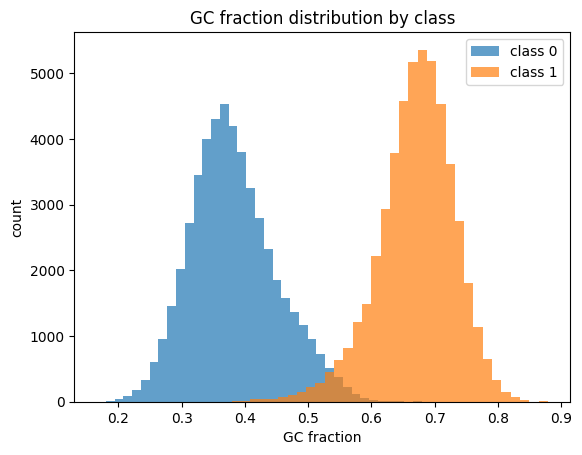


Class 0 has lower GC and Clas 1 has higher GC so GC% is a strong signal for classification


1. **Experiment Setup**: We evaluated two vectorization approaches across k values between 2 and 12: explicit word-tokenized k-mers with CountVectorizer, where sequences are converted to space-separated k-mer strings prior to vectorization, and character n-gram TF-IDF with ranges (3,6), (4,6), (4,7), (3,7), and (5,7). All experiments used 5-fold stratified CV with logistic regression [2][5].

1. **Results**: CountVectorizer with explicit k-mer tokenization peaked at k=4–5 individually but was outperformed by TF-IDF character n-grams. We found that the best performing configuration was TF-IDF, achieving 0.98218 mean CV.

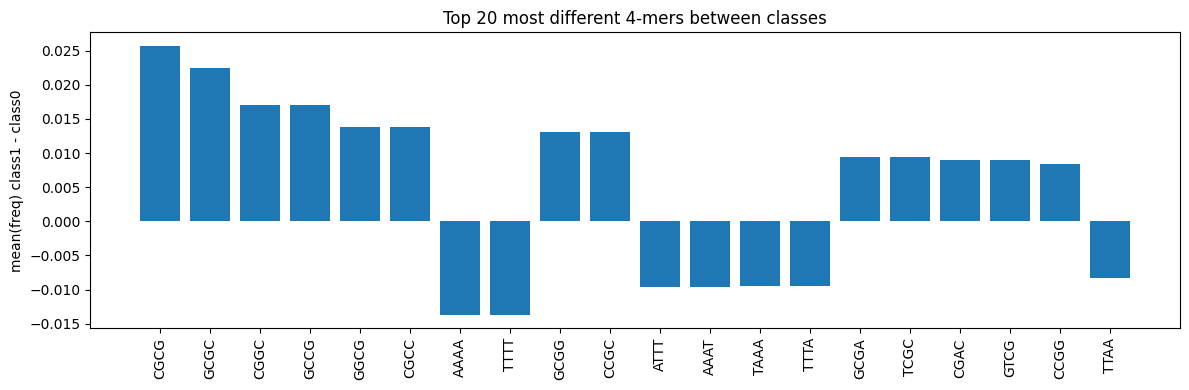


The bars show which 4-base patterns are more common in one class vs the other. Positive is more in class 1 and negative means more in class 0.

1. **Title**: Biologically-Motivated Feature Engineering Improves DNN Classification Beyond K-mer Counting

1. **Idea Discovery**: K-mer frequency analysis revealed that the most discriminative motifs in ambiguous sequences have signal ratios 10–25× weaker than in easy cases, suggesting that these cases could not be solved by k-mer counting alone. We searched the internet for additional domain knowledge and designed five biologically-motivated feature groups based on known sources of inter-species variation in bacterial genomes: reading frame codon composition, homopolymer run structure, CpG dinucleotide bias, relative synonymous codon usage (RSCU), and amino acid composition [11][12].

1. **Finding's Importance**: Different bacterial species exhibit characteristic signatures in codon usage, methylation patterns, and proteome amino acid preferences that are partially independent of overall GC content [11]. These signals are not directly captured by our bag-of-k-mers approaches because they require either frame-aware counting (RSCU, reading frame features) or translation of the nucleotide sequence (amino acid composition). A DNN can exploit nonlinear interactions between these biological features and k-mer counts in ways that logistic regression cannot [2].

1. **Experiment Setup**: Five biological feature groups were computed and evaluated independently and in combination:
- Reading frame 3-mer frequencies were computed by counting 3-mers separately at sequence positions 0, 1, and 2 mod 3, capturing codon-aware composition across all three possible reading frames
- Homopolymer run statistics summarized the mean length, maximum length, and density of consecutive GC and AT runs
- CpG dinucleotide O/E ratios measured the observed vs. expected frequency of CG, TA, GC, and AT dinucleotide pairs
- Relative Synonymous Codon Usage (RSCU) was computed in all three reading frames, normalizing each codon's observed frequency by its expected frequency given the total usage of its synonymous codon group
- Amino acid composition was computed by translating sequences in all 6 reading frames (3 forward, 3 reverse complement) and recording the relative frequency of each of the 20 standard amino acids (120 features)
 Each group was first tested as a standalone feature set with LogReg in 5-fold CV, then all groups were concatenated and combined with the 3+4+5-mer CountVectorizer features as DNN input and scaled with MinMaxScaler [2][5].

1. **Results**: The individual biological features scored below TF-IDF baseline when used with logistic regression (reading frame: 0.98210, homopolymer: 0.97817, CpG: 0.83279, RSCU: 0.97814, amino acid: 0.97955), confirming they are insufficient as standalone features. However, combining all biological features as DNN input alongside k-mer features improved DNN accuracy from 0.98299 (k-mers only) to 0.98432 (k-mers + bio features), a gain of +0.00133. The full biological feature set (507 dimensions) combined with k-mer features (1344 dimensions) as DNN input, blended with TF-IDF LogReg, achieved the best overall local CV score of 0.98467. The improvement over LogReg-only confirms that the DNN finds nonlinear interactions between biological and compositional features that a linear model cannot capture [2][13].


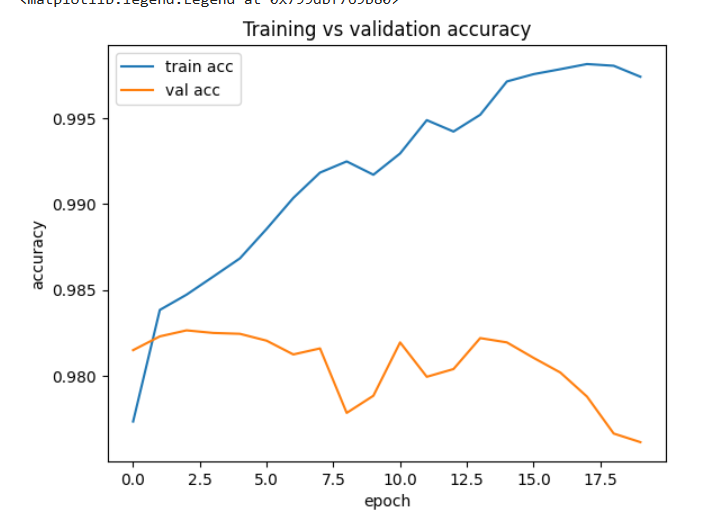

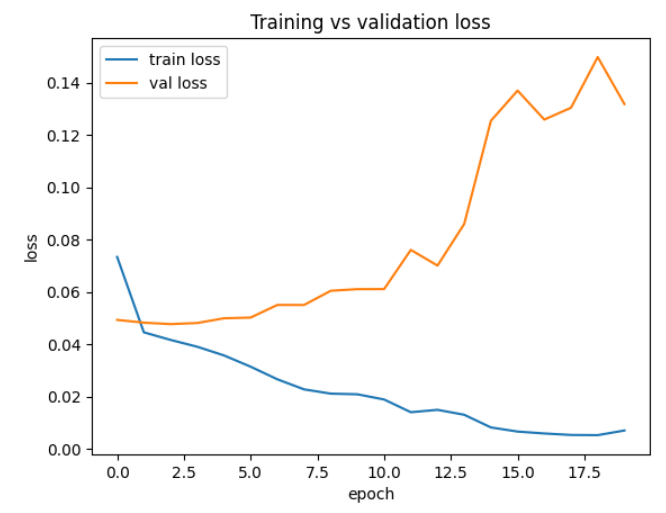


Training accuracy keeps increasing while validation accuracy stays roughly flat and the validation loss rises after a few epochs. This is a clear sign of overfitting, so we relied on early stopping / limiting epochs (and dropout) to select the checkpoint that generalizes best instead of training longer.

<font color=green><h4><b>Task 2. Modeling Ideas</b></h4>
<details>
  <summary>Instructions</summary>
  <div>Explain a <b>key idea</b> that helped with <b>model selection</b> in the format specified above. This may include tuning model parameters (perhaps a grid search with specific parameter range) or some other experiments, search/choice of the suitable model, experiments with postprocessing of model predictions, etc. Use the format in TODO specified above. Remember to provide citation references for the peers to read more into your work.
</div> </details>
</font>

1. **Title**: Blending Logistic Regression and Multi-Seed Deep Neural Network Predictions Reduces Variance and Improves Leaderboard Performance

1. **Idea Discovery**: A disagreement analysis revealed that the Logistic Regression and DNN models disagree on approximately 1.3% of sequences, with neither model consistently correct on disagreements (LogReg: 52.1%, DNN: 47.9%). This suggested the two models capture complementary signal — logistic regression from Term Frequency-Inverse Document Frequency (TF-IDF) character n-gram features and the DNN from CountVectorizer k-mer features combined with biological features — making probability blending a natural combination strategy [2].

1. **Finding's Importance**: Simple probability averaging is a well-established ensemble technique that reduces variance without introducing the complexity or leakage risks of stacking [2]. Since the two models use entirely different feature representations and training procedures, their errors are partially independent, making the blend more robust than either model alone. The blend weight was treated as a hyperparameter to be optimized rather than fixed at 0.5.

1. **Experiment Setup**: Out-of-Fold (OOF) predictions were generated for both models across 5 folds to avoid leakage. Blend weights w(lr) ∈ {0.3, 0.4, 0.5, 0.6, 0.7} were evaluated on the full OOF set. As an alternative to fixed-weight blending, stacking was also tested using meta-learners — LogReg at C ∈ {0.1, 1, 10}, Ridge, and Gradient Boosted Machine (GBM) — trained on OOF predictions from 6 base models (1 LogReg + 5 DNN seeds) [2].

1. **Results**: Stacking (best: 0.98388) did not improve over simple blending (0.98411), suggesting the models make correlated errors on genuinely ambiguous sequences that no meta-learner can resolve. Optimal blend weight was w(lr)=0.4, w(dnn)=0.6, reflecting the DNN's stronger performance when biological features are included. The final blended ensemble — TF-IDF LogReg blended with a 3-seed DNN trained on k-mer and biological features — achieved 0.98467 CV and 0.9863 on the public Leaderboard (LB), representing an improvement of 0.0008 over the single best model alone.

1. **Title**: Random Seed Search Stabilizes Deep Neural Network Ensemble Performance

1. **Idea Discovery**: Deep Neural Network (DNN) training exhibited high variance across random initializations — the same architecture varied by up to 0.006 in validation accuracy across seeds (0.97895–0.98500). This is consistent with the known sensitivity of neural network optimization to weight initialization, particularly on datasets with a small proportion of genuinely hard examples near the decision boundary [2][13]. A systematic seed search was performed to identify initializations that consistently converge to good optima, and to determine whether averaging multiple seeds reduces variance beyond what any single seed achieves.

1. **Finding's Importance**: For a competition with a fixed test set, initialization variance directly affects leaderboard score. A poorly initialized DNN may converge to a suboptimal local minimum, producing unreliable probability estimates near the decision boundary. Averaging predictions across multiple seeds smooths over initialization-dependent errors and produces more stable outputs without changing the model architecture or training procedure [2].

1. **Experiment Setup**: Twenty random seeds (0–19) were evaluated on a fixed 90/10 stratified train/validation split (random_state=42) to ensure a fair comparison. Each seed used identical architecture, features, and training hyperparameters. Seeds were ranked by validation accuracy and the top performers were selected for the final ensemble. A fixed split was used rather than Cross-Validation (CV) to ensure rankings reflect true seed performance rather than split-dependent variance [2][14].

1. **Results**: Seed performance ranged from 0.98130 to 0.98400 across 20 seeds, a spread of 0.0027. Top seeds were 5 (0.98400), 1 (0.98350), and 3 (0.98330). Ensembling seeds 1, 3, and 5 achieved higher and more stable CV

<font color=green><h3><b>$\zeta$. References</b></h3>
<details>
  <summary>Instructions</summary>
  <div>

1. Cite your sources to help your peers learn from these (and to avoid plagiarism).
1. HOML textbook should be cited, since we used it in this week's learning.
1. Use Google Scholar to draw [APA](https://en.wikipedia.org/wiki/American_Psychological_Association) citation format for books and publications.
1. Cite [StackOverflow](https://stackoverflow.com/), YouTube videos, package docs, open-access textbooks/publicaitons and other meaningful internet resources that you used.
1. We may reward exceptional and meaningful citations (not just a list of [SKL](https://scikit-learn.org/stable/)/[TF](https://www.tensorflow.org/) manual pages and a list of articles.) For example, if you used an idea from a publication, indicate it in TGP with a number that corresponds to its reference in References.

</div> </details>
</font>

1. Akkaya, Ü. M., et al. *Classification of DNA Sequences with k-mers Based Vector Representations*. ASYU. [2021](https://doi.org/10.1109/ASYU52992.2021.9599084)

1. Géron, A. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media. [2022](https://scholar.google.com/scholar?cluster=498861685923226475)

1. Ji, S., et al. *DNABERT: pre-trained Bidirectional Encoder Representations from Transformers model for DNA-language in genome*. Bioinformatics, 37(15), 2112–2120. [2021](https://doi.org/10.1093/bioinformatics/btab083)

1. Akotenou, G., El Allali, A. *Genomic language models (gLMs) decode bacterial genomes for improved gene prediction and translation initiation site identification*. Briefings in Bioinformatics, 26(4), bbaf311. [2025](https://doi.org/10.1093/bib/bbaf311)

1. Ren, J., et al. *Likelihood ratios for out-of-distribution detection*. NeurIPS, 14707–14718. [2019](https://proceedings.neurips.cc/paper/2019)

1. Reimers, N., Gurevych, I. *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks*. EMNLP. [2019](https://doi.org/10.18653/v1/D19-1410)

1. Dalla-Torre, H., et al. *The Nucleotide Transformer: Building and Evaluating Robust Foundation Models for Human Genomics*. bioRxiv. [2023](https://doi.org/10.1101/2023.01.11.523679)

1. Avsec, Ž., et al. *Effective gene expression prediction from sequence by integrating long-range interactions*. Nature Methods, 18, 1196–1203. [2021](https://doi.org/10.1038/s41592-021-01252-x)

1. Moeckel, C., et al. *A survey of K-Mer Methods and Applications in bioinformatics*. Computational and Structural Biotechnology Journal, 23, 2289–2303. [2024](https://doi.org/10.1016/j.csbj.2024.05.025)

1. Clavijo, B. J. *k-mer counting, part I: Introduction*. BioInfoLogics. [2018](https://bioinfologics.github.io/post/2018/09/17/k-mer-counting-part-i-introduction)

1. Kurmi, A., et al. *Differentially used codons among essential genes in bacteria identified by ML-based analysis*. Molecular Genetics and Genomics, 299(1), 72. [2024](https://doi.org/10.1007/s00438-024-02163-0)

1. Suzek, B. E., et al. *A probabilistic method for identifying start codons in bacterial genomes*. Bioinformatics, 17(12), 1123–1130. [2001](https://doi.org/10.1093/bioinformatics/17.12.1123)

1. Glorot, X., Bengio, Y. *Understanding the difficulty of training deep feedforward neural networks*. AISTATS, 249–256. [2010](https://proceedings.mlr.press/v9/glorot10a.html)

1. Loshchilov, I., Hutter, F. *Decoupled Weight Decay Regularization*. ICLR. [2019](https://arxiv.org/abs/1711.05101)

1. Wikipedia contributors. *Codon usage bias*. [Wikipedia](https://en.wikipedia.org/wiki/Codon_usage_bias)

1. Wikipedia contributors. *K-mer*. [Wikipedia](https://en.wikipedia.org/wiki/K-mer)

1. Anthropic. *Claude Sonnet 4.5* [Large language model]. Used for code generation, experimental design, and text drafting throughout this notebook. https://claude.ai (2025)

<hr color=green size=40><strong><font color=green size=5>⌛End of TGP. Do not exceed RTL! Do not write code outside TGP.</font></strong>
<!--<hr color=green size=40>-->

In [ ]:
tmr.ShowTime()    # measure Colab's runtime. Do not remove. Keep as the last cell in your notebook.

Runtime is 533 sec > 300 sec limit!!!


<details>
  <summary><font size=5><b>💡Starter Ideas</b></font></summary>
  <div>
  
Try [**Common Starter Ideas**](https://colab.research.google.com/drive/1riOGrE_Fv-yfIbM5V4pgJx4DWcd92cZr#scrollTo=oD-fFbF2ZSBl&line=1&uniqifier=1)

#### **Preprocessing**
1. Try a larger training sample.
1. Try longer training DNA strings, but SBERT may have a cap on string length, so you might split DNA into several strings and then concatenate or average resulting vectors
1. Try other pretrained SBERT models. Note that DNA sequence uses ACGT letters, but many other models were trained on multilingual text. So, you might prefer those that were trained on mostly ASCII.
1. SBERT is trained on word tokens (typically, separated by spaces), but DNA sequence has no spaces. Try placing spaces after every character or some semantically meaningful subsequences (this might require more domain knowledge).
1. Try Google's [USE](https://tfhub.dev/google/universal-sentence-encoder-multilingual/3) embedding models
1. Try Facebook's [LASER](https://github.com/facebookresearch/LASER) and [others](https://tfhub.dev/s?module-type=text-language-model).
1. Try [Enformer](https://tfhub.dev/deepmind/enformer/1) for gene expressions. See [DeepMind paper](https://deepmind.com/blog/article/enformer).
1. Try building your own embeddings on the given sequences. SBERT and other packages make it easy (just a few lines), but it may take too much time.
1. Assess distribution of character patterns (single, doubles, triplets, ...). For example, an ACGT string generates AC, CG, GT doubles and ACG and CGT triplets. Does one class have more subsequences of some type? This might be a feature in your model.
1. Try features built as counts of subsequences (singles, doubles, triplets, ...). Consider EDA first.
1. Concatenate or otherwise combine multiple embeddings derived from each gene string
1. Try [Byte Pair Encoding](https://www.derczynski.com/papers/archive/BPE_Gage.pdf) and [SentencePiece](https://arxiv.org/pdf/1808.06226.pdf) to auto identification of "important" [k-mers](https://en.wikipedia.org/wiki/K-mer) (substrings)

### **Summarized ideas from past participants**
1. Acc=0.9868, rank=1, SP25:
    1. **Preprocessing:** SBERT encoding, transforming the sequence data into 384-dimensional embedding vectors. Next, k-mer counting features were generated and added to enrich the representation with biologically meaningful sequence patterns. These k-mer features were then scaled using either a Standard Scaler or MinMax Scaler, with experimentation demonstrating that the MinMax Scaler provided superior performance.
    1. **Modeling:** a DNN with 3 layers was employed, incorporating an exponential decay learning rate for training stability and efficiency. Extensive trials were conducted comparing activation functions (ReLU, Leaky ReLU, GELU), ultimately favoring GELU for this dataset. Multiple SBERT models were evaluated, with `paraphrase-MiniLM-L3-v2` selected for its optimal trade-off between accuracy and speed. Hyperparameter search revealed that, despite the problem's complexity, a two-layer network with 150 neurons each almost matched deeper networks, but the final three-layer setup yielded the best overall result.
1. Acc=0.9868, rank=2, SP25:
    1. **Preprocessing:** The team focused on feature engineering by using k-mer frequency counts to numerically represent DNA sequences, as k-mers are a proven approach for genomic data. They experimented with several ways to extract k-mers and performed local 5-fold CV to optimize accuracy. Additionally, they tuned parameters such as k-mer length, sequence truncation, and the maximum number of vectorization features, all contributing to noticeable accuracy gains.
    1. **Modeling:** After recognizing the complexity of their DNN and preprocessing pipeline, the team used Optuna, a Bayesian optimization framework, to efficiently explore a vast hyperparameter space. This included tuning DNN architecture parameters (like layer units, dropouts, activation functions, batch size, and learning rate) and vectorization parameters. Implementing this approach led to further measurable improvements, advancing their model's LB ranking. The decision to use Bayesian optimization over grid search was driven by the impracticality of exhaustively searching such a large, conditional parameter space.
1. Acc=0.9864, rank=3, SP25:
    1. **Preprocessing:** K-mer encoding was used to convert DNA sequences into structured numerical feature vectors, with k-mers of length 3, 4, and 5 extracted. K-mer frequencies provided biologically informative features and enabled dimensionality reduction, turning variable-length sequences into fixed-length vectors (e.g., 64 for k=3, 256 for k=4). Feature vectors were normalized with StandardScaler. Combining 3-mer and 4-mer features led to the best performance, capturing complementary sequence patterns for improved classification.
    1. **Modeling:** A baseline linear SVC was compared to a deeper DNN, motivated by DNN's capacity to capture complex, hierarchical patterns in DNA not reachable by linear methods. The DNN was implemented as a 3-layer dense model with ReLU activation, batch normalization, and dropout, trained with the Adam optimizer and binary cross-entropy loss. Experiments included careful hyperparameter choices (e.g., dropout ratio, batch size) and validation via 5-fold CV and an 80/20 split. The DNN significantly outperformed the linear SVC, confirming its strength for this classification task.
1. Acc=0.9854, rank=2, FA24
    1. **Preprocessing:** We converted DNA letter sequences into numerical features suitable for ML models. Two main encoding strategies were tested: k-mer frequency counting, which breaks sequences into substrings of 'k' length and counts their frequencies, and reading frame encoding, which considers nucleotide reading frames. PCA and feature standardization did not improve performance with k-mer encoding. Ultimately, k-mer frequency counting emerged as the most effective strategy.
    1. **Modeling:** We explored various DNN architectures with emphasis on hyperparameter tuning and k-fold CV. A wide and shallow network using SELU activation and LeCun normal initialization outperformed larger, deeper models, which tended to overfit. Adjustments such as lowering the learning rate and customizing the sigmoid threshold further improved validation accuracy, while modifications like increased epochs and dropout were detrimental. The final chosen model balanced generalization and accuracy, achieving strong leaderboard performance.
1. Acc=0.9853, rank=3, FA24
    1. **Preprocessing:** The approach leveraged k-mer analysis using `CountVectorizer` from sklearn, treating DNA sequences as text where each nucleotide is a character. By extracting k-mer (n-gram) features directly from the raw DNA, this method efficiently encoded local and extended sequence patterns without the computational burden of deep embeddings. This efficient, text-like processing allowed the use of the entire dataset within strict runtime limits while still capturing biologically relevant motifs.
    1. **Modeling:** A logistic regression model was chosen for its computational efficiency and ability to handle high-dimensional k-mer features with strong regularization. Extensive grid search was performed over solvers (e.g., lbfgs, liblinear), regularization types (l1, l2), and strengths to optimize accuracy and runtime. The final configuration—lbfgs solver with L2 regularization and a fine-tuned strength—achieved high accuracy on the leaderboard while remaining within runtime constraints, outperforming faster but less accurate alternatives.

### **Further resources:**
1. Akiba, T., et al. *Optuna: A next-generation hyperparameter optimization framework*. [2019](https://doi.org/10.48550/arXiv.1907.10902)
1. Akkaya, Ü. M., et al. *Classification of DNA Sequences with k-mers Based Vector Representations*. 2021 Innovations in Intelligent Systems and Applications Conference (ASYU), 1-6. [2021](https://doi.org/10.1109/ASYU52992.2021.9599084)
1. Bonat, Ernest. *Apply Machine Learning Algorithms for Genomics Data Classification*. [2021](https://medium.com/mlearning-ai/apply-machine-learning-algorithms-for-genomics-data-classification-132972933723)
1. Clark, David P. et al. *Reading Frame. An Overview*. ScienceDirect Topics. [2013](https://www.sciencedirect.com/topics/neuroscience/reading-frame)
1. Clavijo, Bernardo J. . *k-mer counting, part I: Introduction*. BioInfoLogics. [9/17/18](https://bioinfologics.github.io/post/2018/09/17/k-mer-counting-part-i-introduction)
1. Hale, J. *Don’t Sweat the Solver Stuff*. Towards Data Science. Medium. [11/12/21](https://towardsdatascience.com/dont-sweat-the-solver-stuff-aea7cddc3451)
1. Khan Academy authors. *The genetic code*. Khan Academy. [link](https://www.khanacademy.org/science/ap-biology/gene-expression-and-regulation/translation/a/the-genetic-code-discovery-and-properties)
1. Kurmi, A., et al. *Differentially used codons among essential genes in bacteria identified by ML-based analysis*. Molecular genetics and genomics : MGG, 299(1), 72. [2024](https://doi.org/10.1007/s00438-024-02163-0)
1. Melsted, Páll, et al. *Efficient counting of k-mers in DNA sequences using a bloom filter*. [2011](https://bmcbioinformatics.biomedcentral.com/articles/10.1186/1471-2105-12-333)
1. Meydan, S., et al. *Identification of Translation Start Sites in Bacterial Genomes*. Methods in molecular biology (Clifton, N.J.), 2252, 27–55. [2021](https://doi.org/10.1007/978-1-0716-1150-0_2)
1. Moeckel, C., et al. *A survey of K-Mer Methods and Applications in bioinformatics*. Computational and Structural Biotechnology Journal, 23, 2289–2303. [2024](https://doi.org/10.1016/j.csbj.2024.05.025) or [link](https://www.sciencedirect.com/science/article/pii/S2001037024001703)
1. Pechenizkiy, M. et al. *PCA-based feature transformation for classification: Issues in medical diagnostics*. Proceedings. 17th IEEE Symposium on Computer-Based Medical Systems. [2004](https://doi.org/10.1109/cbms.2004.1311770)
1. Pykes, K. *Fighting overfitting with L1 or L2 regularization: Which one is better?* neptune.ai. [8/4/23](https://neptune.ai/blog/fighting-overfitting-with-l1-or-l2-regularization)
1. Shchelochkov, Oleg A. *Open reading frame*. Genome.gov. [2025](https://www.genome.gov/genetics-glossary/Open-Reading-Frame)
1. Suzek, Baris E., et al. *A probabilistic method for identifying start codons in bacterial genomes*. Bioinformatics, v17, iss 12, pp.1123–1130, [12/2001](https://doi.org/10.1093/bioinformatics/17.12.1123)
1. Wikipedia contributors. *K-mer*. [7/11/24](https://en.wikipedia.org/wiki/K-mer)
1. Youtube authors. Learn about DNA [&#127910;](https://www.youtube.com/results?search_query=nucleotides+genes+amino+acids+)

</div> </details>
